Head of national monthly series:
                  GWh
Date                 
2019-01-01  220536.86
2019-02-01  201677.30
2019-03-01  234222.44
2019-04-01  237810.94
2019-05-01  258264.44

Coverage: 2019-01-01 → 2025-07-01
Unit: ['GWh']

Saved aggregated series to: outputs_energy_ts/india_total_electricity_generation_monthly.csv


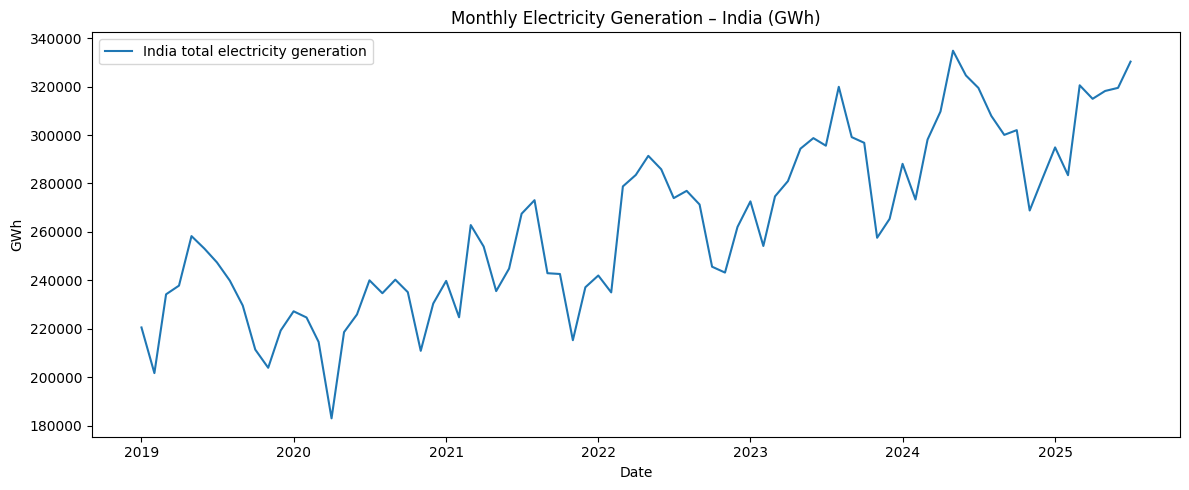

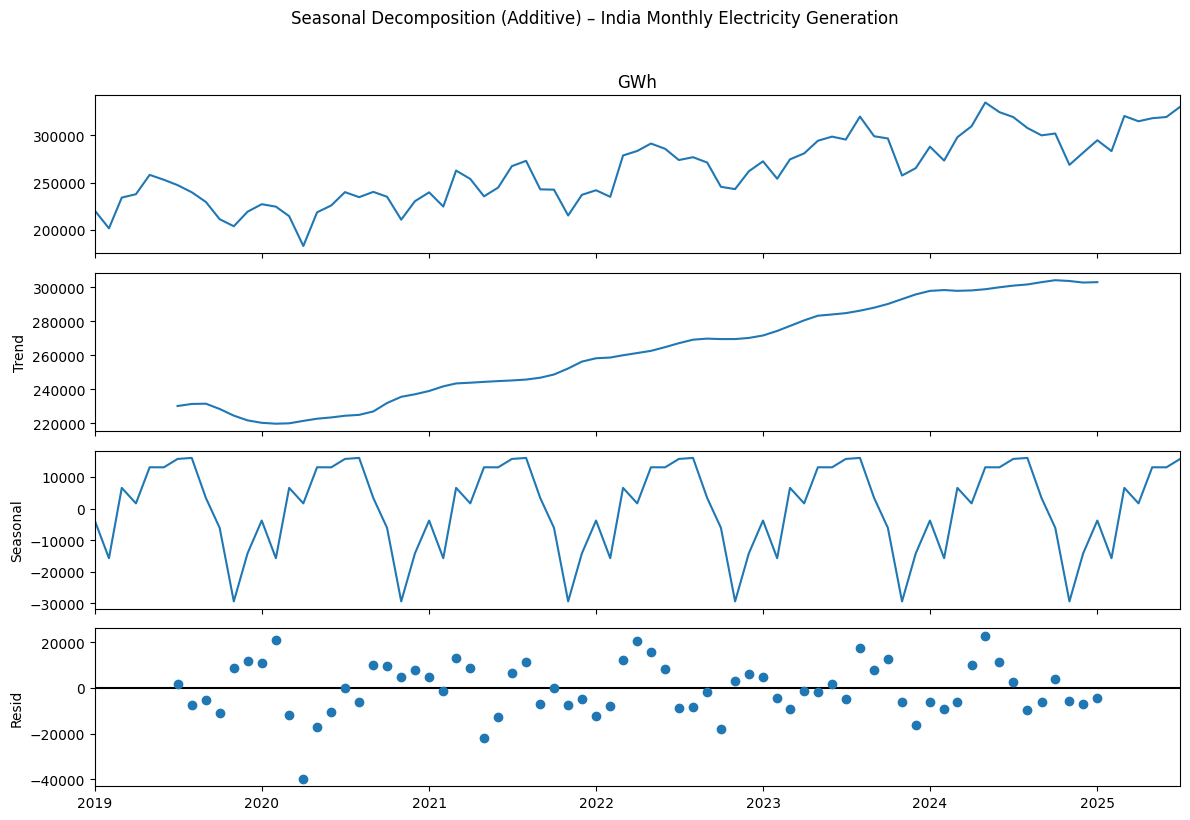

ADF (level): stat=0.326, p-value=0.9785
ADF (1st diff): stat=-6.181, p-value=0.0000


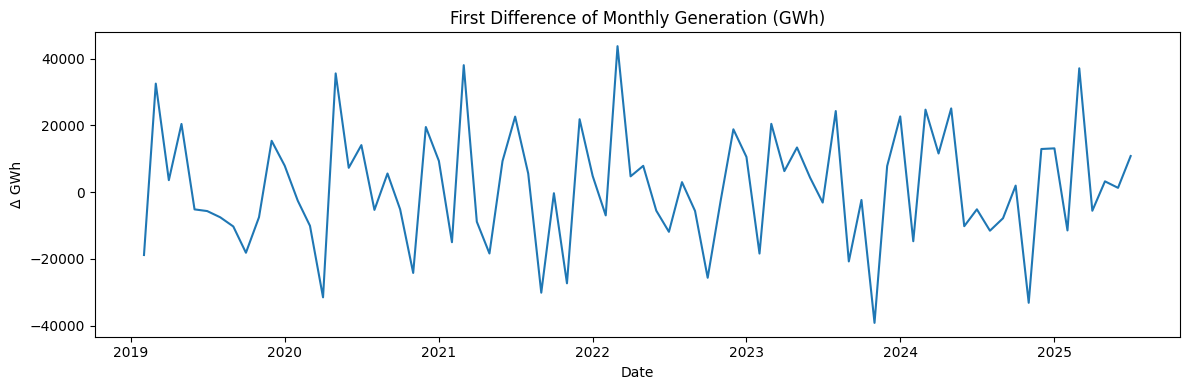


Best SARIMA order: (1, 1, 1), seasonal: (0, 1, 1, 12), AIC: 1152.885


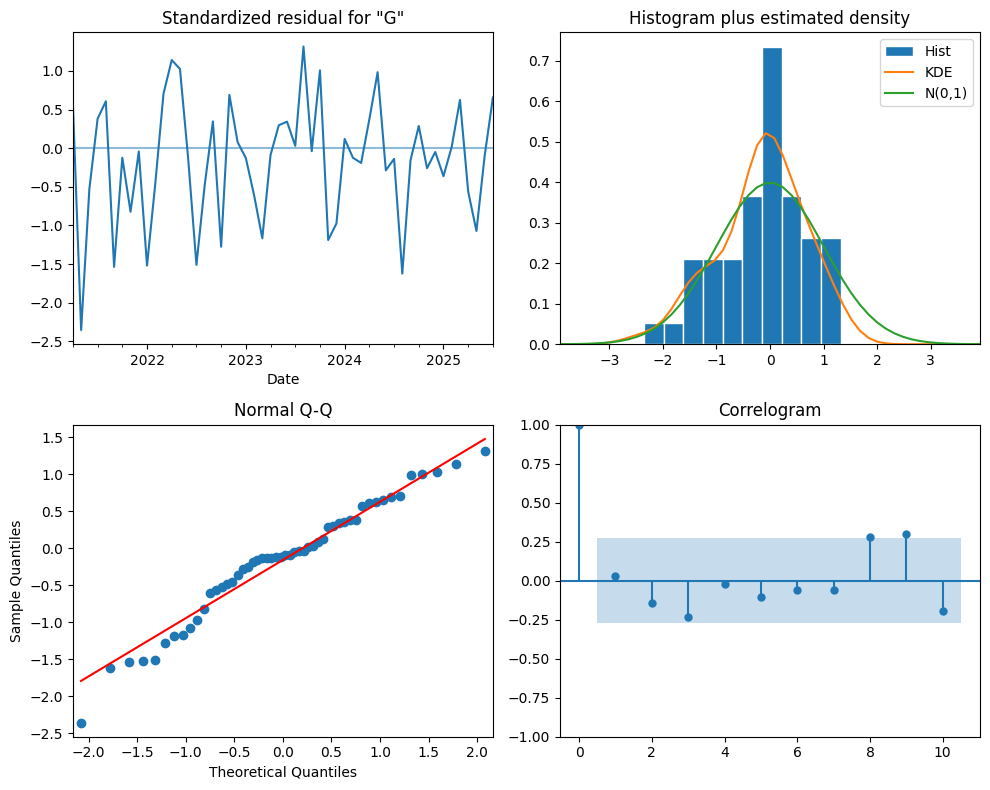

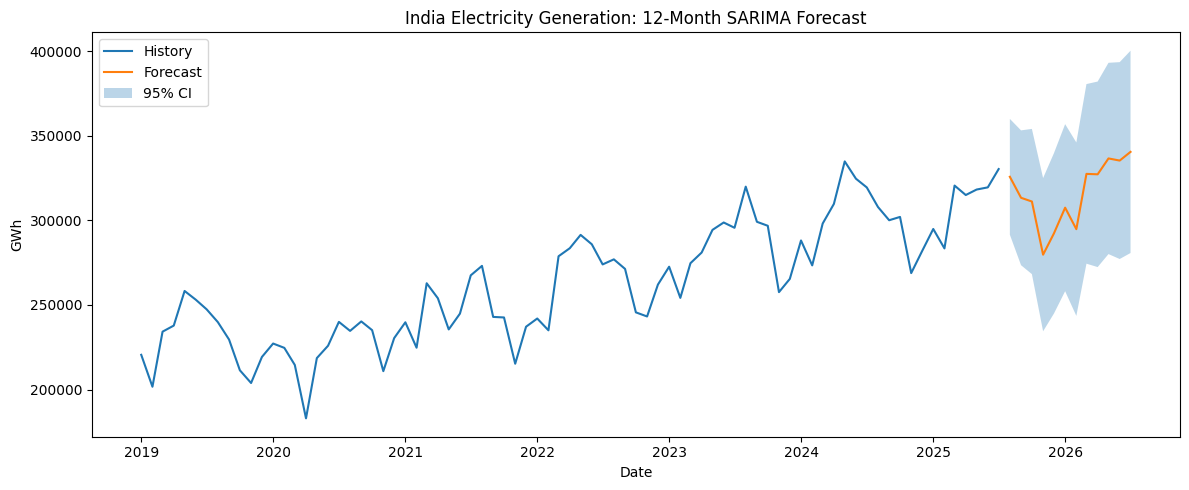

Saved forecast table to: outputs_energy_ts/forecast_12m.csv

DONE. Files saved in: outputs_energy_ts


In [ ]:
# === India Electricity Generation (Ember long-format) ===
# From: india_monthly_full_release_long_format.csv
# Analysis: aggregate to national monthly total, decompose, ADF, SARIMA, forecast

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ------------------------------
# 0) CONFIG
# ------------------------------
# Change this to your CSV path:
CSV_PATH = "india_monthly_full_release_long_format.csv"
SAVE_DIR = "outputs_energy_ts"
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------
# 1) LOAD & INSPECT
# ------------------------------
df = pd.read_csv(CSV_PATH)

# Basic sanity checks
expected_cols = {"Country","Country code","State","State code","State type",
                 "Date","Category","Subcategory","Variable","Unit","Value"}
missing = set(["Date","Category","Subcategory","Value"]) - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns in CSV: {missing}")

# ------------------------------
# 2) FILTER TO TOTAL ELECTRICITY GENERATION
# ------------------------------
# In Ember long-format, the total monthly generation lives under:
# Category = "Electricity generation", Subcategory = "Total"
gen_total = df[(df["Category"] == "Electricity generation") &
               (df["Subcategory"] == "Total")].copy()

# Keep only what we need
gen_total = gen_total[["Date", "State", "Unit", "Value"]]

# Convert date and drop rows with missing values
gen_total["Date"] = pd.to_datetime(gen_total["Date"], errors="coerce")
gen_total = gen_total.dropna(subset=["Date","Value"])

# Optional: ensure numeric Value
gen_total["Value"] = pd.to_numeric(gen_total["Value"], errors="coerce")
gen_total = gen_total.dropna(subset=["Value"])

# ------------------------------
# 3) AGGREGATE TO NATIONAL MONTHLY TOTAL
# ------------------------------
# Sum across all states for each month → national total (GWh)
india_monthly = (
    gen_total.groupby("Date")["Value"]
    .sum()
    .sort_index()
    .to_frame(name="GWh")
)

# Make it a proper monthly series (month-start frequency)
india_monthly = india_monthly.asfreq("MS")

print("Head of national monthly series:")
print(india_monthly.head())
print("\nCoverage:", india_monthly.index.min().date(), "→", india_monthly.index.max().date())
print("Unit:", gen_total["Unit"].dropna().unique())

# Save the aggregated time series (optional; comment out if you don't want files)
agg_path = os.path.join(SAVE_DIR, "india_total_electricity_generation_monthly.csv")
india_monthly.to_csv(agg_path)
print(f"\nSaved aggregated series to: {agg_path}")

# ------------------------------
# 4) PLOTS: HISTORY
# ------------------------------
plt.figure(figsize=(12,5))
plt.plot(india_monthly.index, india_monthly["GWh"], label="India total electricity generation")
plt.title("Monthly Electricity Generation – India (GWh)")
plt.xlabel("Date"); plt.ylabel("GWh")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "01_history.png"), dpi=180)
plt.show()

# ------------------------------
# 5) SEASONAL DECOMPOSITION
# ------------------------------
# Additive decomposition with 12-month seasonality
decomp = seasonal_decompose(india_monthly["GWh"], model="additive", period=12)
fig = decomp.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Seasonal Decomposition (Additive) – India Monthly Electricity Generation", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "02_decomposition.png"), dpi=180, bbox_inches="tight")
plt.show()

# ------------------------------
# 6) STATIONARITY (ADF)
# ------------------------------
y = india_monthly["GWh"]

adf_lvl = adfuller(y.dropna())
print(f"ADF (level): stat={adf_lvl[0]:.3f}, p-value={adf_lvl[1]:.4f}")

y_diff = y.diff().dropna()
adf_diff = adfuller(y_diff)
print(f"ADF (1st diff): stat={adf_diff[0]:.3f}, p-value={adf_diff[1]:.4f}")

plt.figure(figsize=(12,4))
plt.plot(y_diff)
plt.title("First Difference of Monthly Generation (GWh)")
plt.xlabel("Date"); plt.ylabel("Δ GWh")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "03_first_difference.png"), dpi=180)
plt.show()

# ------------------------------
# 7) COMPACT SARIMA GRID (choose by AIC)
# ------------------------------
# Given monthly utility series and sample length (2019+), a compact grid is sensible
p = q = range(0, 2)     # {0,1}
d = [1]                 # non-seasonal differencing typically 1
P = Q = range(0, 2)     # {0,1}
D = [1]                 # seasonal differencing typically 1 for monthly utilities
s = 12

best_aic = np.inf
best_order = None
best_seasonal = None
best_res = None

for pi in p:
    for di in d:
        for qi in q:
            for Pi in P:
                for Di in D:
                    for Qi in Q:
                        try:
                            model = SARIMAX(
                                y,
                                order=(pi, di, qi),
                                seasonal_order=(Pi, Di, Qi, s),
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            )
                            res = model.fit(disp=False)
                            if res.aic < best_aic:
                                best_aic = res.aic
                                best_order = (pi, di, qi)
                                best_seasonal = (Pi, Di, Qi, s)
                                best_res = res
                        except Exception as e:
                            # Skip combos that fail to converge
                            pass

print(f"\nBest SARIMA order: {best_order}, seasonal: {best_seasonal}, AIC: {best_aic:.3f}")

# Diagnostics
if best_res is not None:
    diag = best_res.plot_diagnostics(figsize=(10,8))
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "04_diagnostics.png"), dpi=180)
    plt.show()
else:
    raise RuntimeError("No SARIMA model could be fitted. Check your data.")

# ------------------------------
# 8) FORECAST (12 months)
# ------------------------------
steps = 12
fc_res = best_res.get_forecast(steps=steps)
fc_mean = fc_res.predicted_mean
fc_conf = fc_res.conf_int()

# Ensure numeric for plotting
for col in fc_conf.columns:
    fc_conf[col] = pd.to_numeric(fc_conf[col], errors="coerce")

plt.figure(figsize=(12,5))
plt.plot(y.index, y, label="History")
plt.plot(fc_mean.index, fc_mean, label="Forecast")
plt.fill_between(fc_mean.index, fc_conf.iloc[:,0].values, fc_conf.iloc[:,1].values, alpha=0.3, label="95% CI")
plt.title("India Electricity Generation: 12-Month SARIMA Forecast")
plt.xlabel("Date"); plt.ylabel("GWh")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "05_forecast.png"), dpi=180)
plt.show()

# Save forecast table
fc_table = pd.DataFrame({
    "forecast_GWh": fc_mean,
    "lower_95": fc_conf.iloc[:,0],
    "upper_95": fc_conf.iloc[:,1],
})
fc_path = os.path.join(SAVE_DIR, "forecast_12m.csv")
fc_table.to_csv(fc_path)
print(f"Saved forecast table to: {fc_path}")

print("\nDONE. Files saved in:", SAVE_DIR)
